In [16]:
# from cluster_paths import get_cluster_paths
# scratch_path, repo_path = get_cluster_paths()
scratch_path = "/iopsstor/scratch/cscs/athomsen"
repo_path = "/users/athomsen/dlss/repos"

%load_ext autoreload
%autoreload 2

import os, h5py
import numpy as np
import matplotlib.pyplot as plt
from trianglechain import TriangleChain

from msfm.utils import files
from msi.utils import input_output

rng = np.random.default_rng(12)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# v16

In [17]:
# subversion = "default"
subversion = "no_sc"

msfm_conf = files.load_config(f"{repo_path}/multiprobe-simulation-forward-model/configs/v16/{subversion}.yaml")

## maps

In [18]:
base_dir = f"{scratch_path}/deep_lss/runs/v16/{subversion}/maps"

In [19]:
probe = "lensing"
params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta"]

# # model_name = "v5"
# # n_steps = 360_000

# # model_name = "v1"
# # n_steps = 300_000

# model_name = "v1_vicreg"
# n_steps = 100_000

model_name = "v1_inv"
n_steps = 100_000

In [20]:
# probe = "clustering"

# model_name = "v5"
# n_steps = 180_000

In [21]:
# probe = "combined"

# model_name = "v1"
# n_steps = 150_000

In [ ]:
probe = "lensing"
params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta"]

# # model_name = "v5"
# # n_steps = 360_000

# # model_name = "v1"
# # n_steps = 300_000

# model_name = "v1_vicreg"
# n_steps = 100_000

model_name = "v1_inv"
n_steps = 100_000

## common

# prior predictive checks

## scatterplot

In [22]:
pred_dir = os.path.join(base_dir, probe, model_name)
pred_file = os.path.join(pred_dir, f"preds_{n_steps}.h5")
print(f"pred_file = {pred_file}")

grid_preds, grid_cosmos, _, _ = input_output.load_network_preds_simple(pred_file)


pred_file = /iopsstor/scratch/cscs/athomsen/deep_lss/runs/v16/no_sc/maps/lensing/v1_inv/preds_100000.h5
26-05-05 08:59:48 input_output INF   Loading predictions from /iopsstor/scratch/cscs/athomsen/deep_lss/runs/v16/no_sc/maps/lensing/v1_inv/preds_100000.h5 
26-05-05 08:59:48 input_output INF   grid_preds.shape = (200000, 12) 
26-05-05 08:59:48 input_output INF   grid_cosmos.shape = (200000, 6) 
26-05-05 08:59:48 input_output INF   DESy3 with shape (12,) 
26-05-05 08:59:48 input_output INF   bench_bsc=0_mean with shape (12,) 
26-05-05 08:59:48 input_output INF   bench_bsc=0_stack with shape (80, 12) 
26-05-05 08:59:48 input_output INF   bench_bsc=1_mean with shape (12,) 
26-05-05 08:59:48 input_output INF   bench_bsc=1_stack with shape (80, 12) 
26-05-05 08:59:48 input_output INF   bench_bsc=fit_mean with shape (12,) 
26-05-05 08:59:48 input_output INF   bench_bsc=fit_stack with shape (80, 12) 
26-05-05 08:59:48 input_output INF   bench_bsc=rot_mean with shape (12,) 
26-05-05 08:59:48 

100%|██████████| 66/66 [00:00<00:00, 554.88it/s]


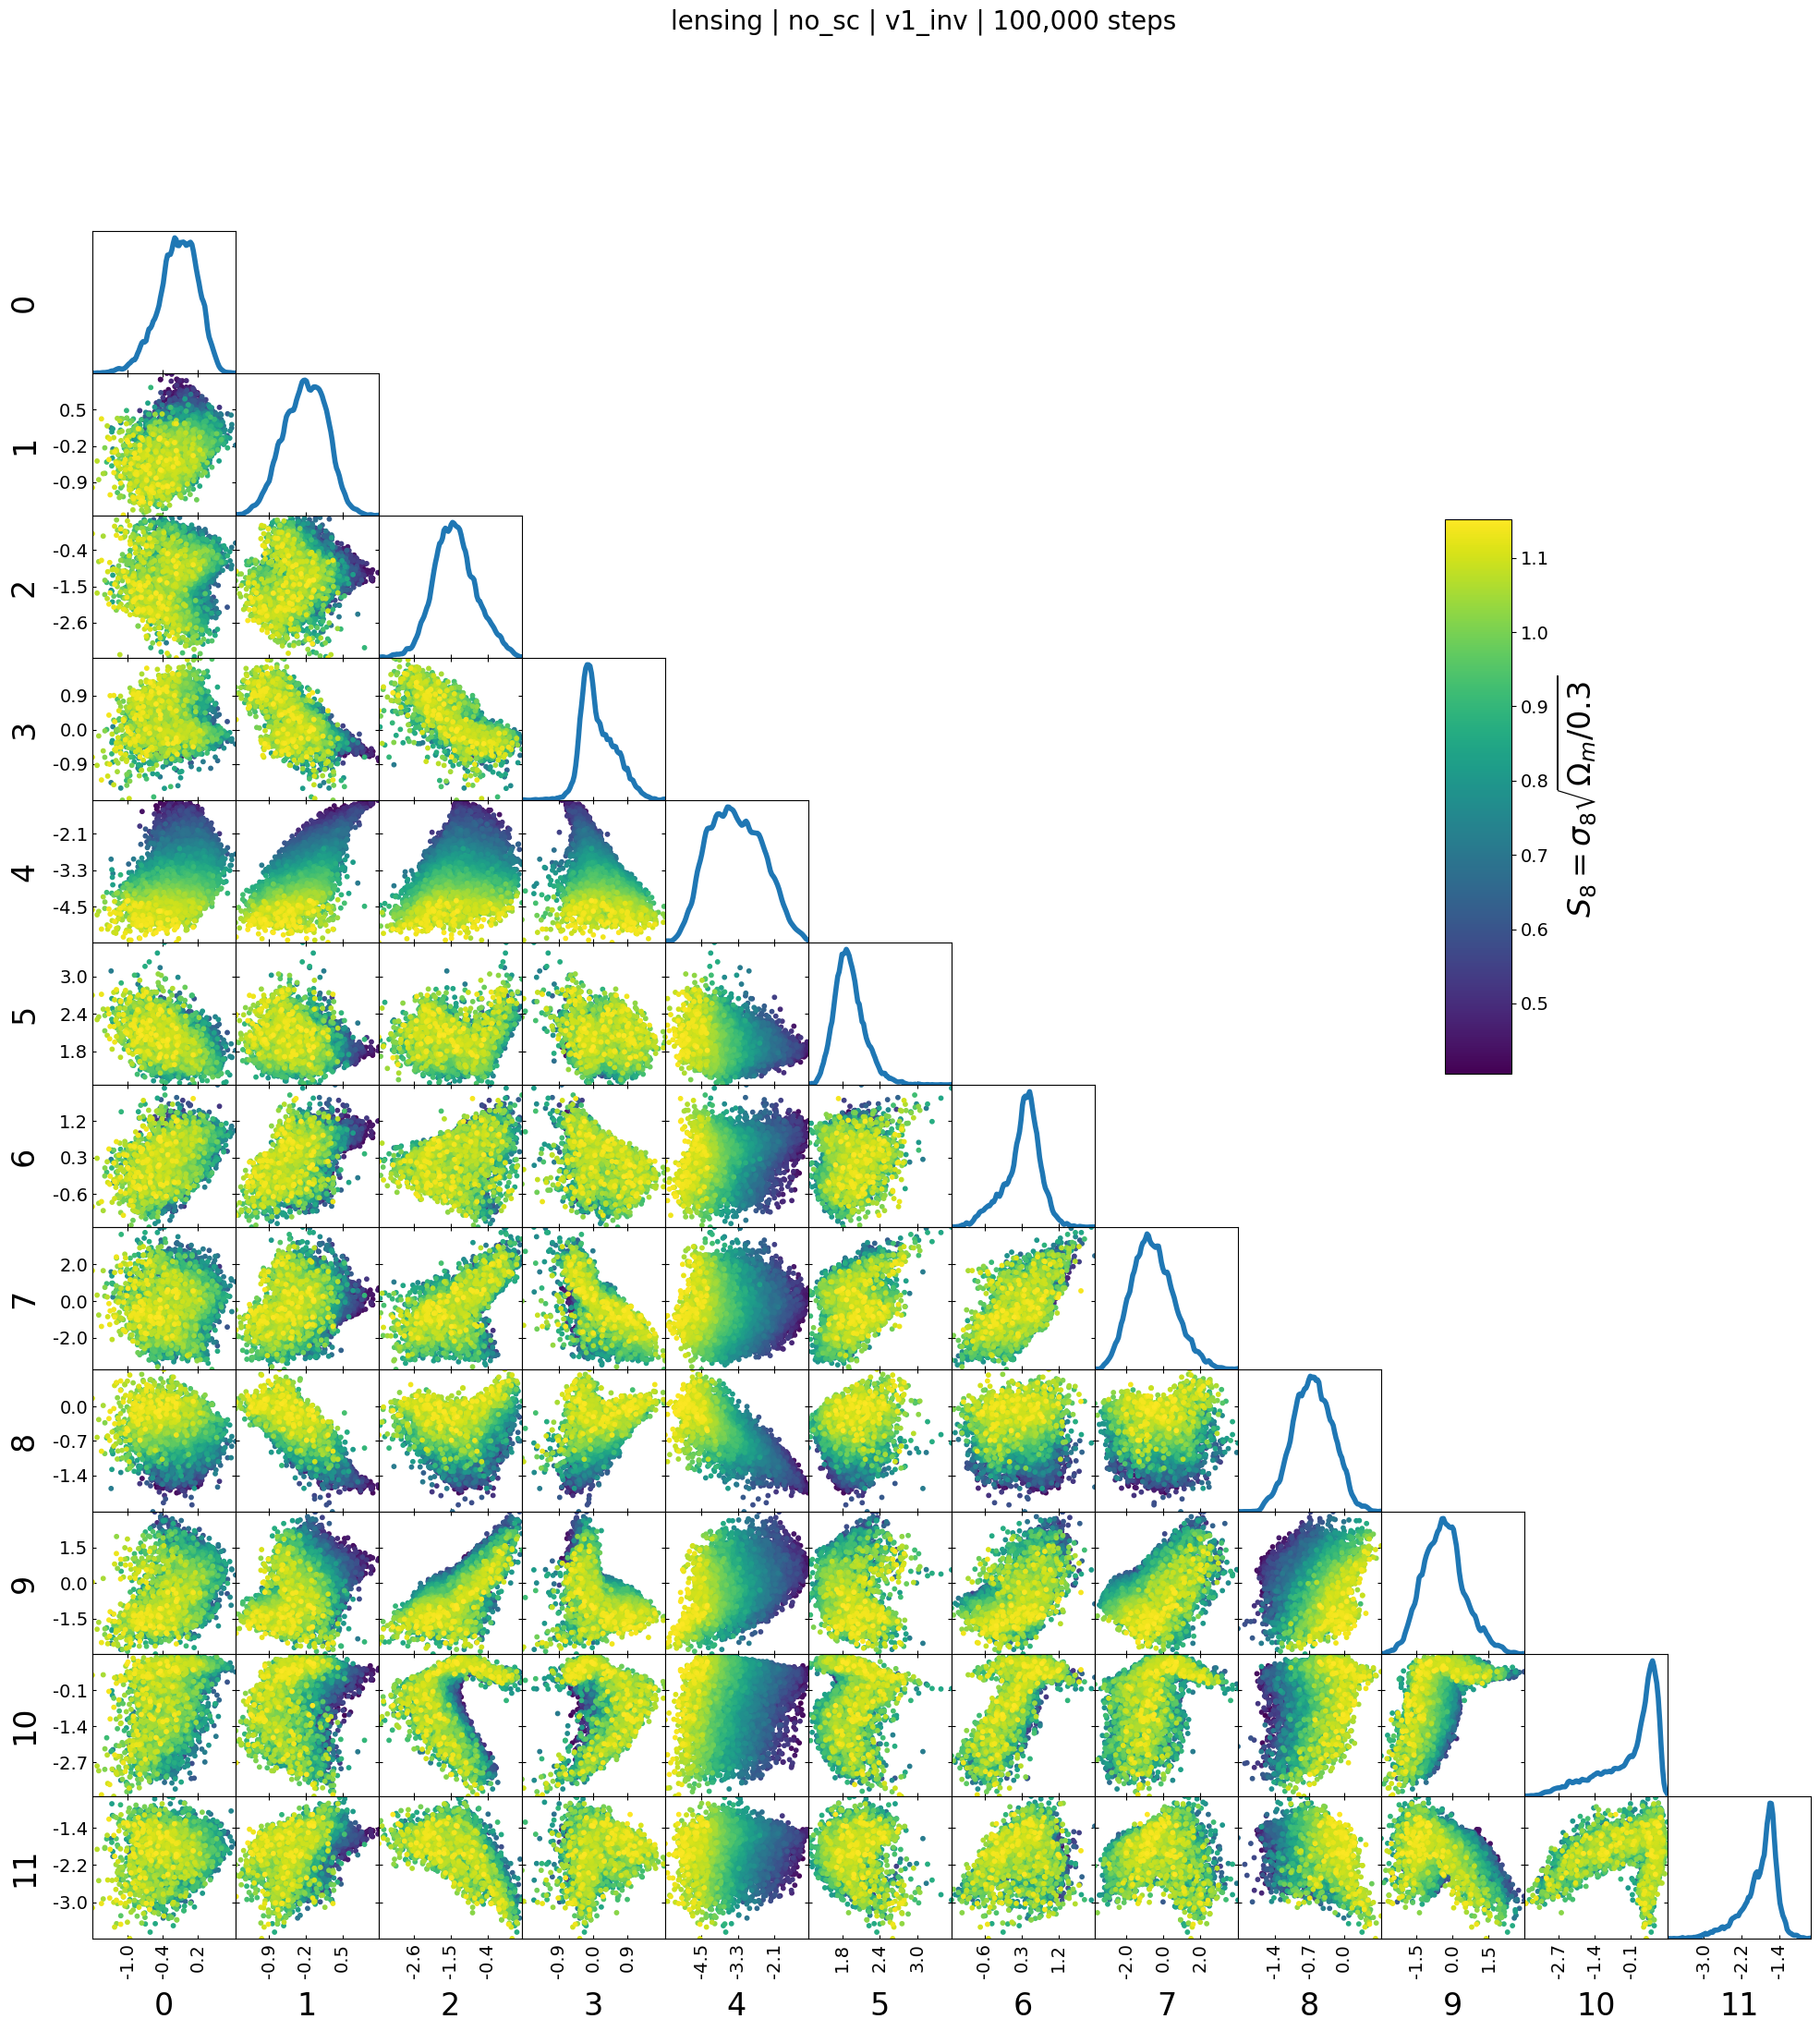

In [23]:
i_rand = rng.integers(0, grid_preds.shape[0], 10_000)

i_Om = params.index("Om")
i_s8 = params.index("s8")
S8 = grid_cosmos[i_rand, i_s8] * np.sqrt(grid_cosmos[i_rand, i_Om] / 0.3)

tri = TriangleChain(
    size=2,
    cmap="viridis",
    colorbar=True,
    colorbar_label=r"$S_8 = \sigma_8 \sqrt{\Omega_m / 0.3}$",
)
tri.scatter_prob(
    np.array(grid_preds)[i_rand],
    prob=S8,
    scatter_kwargs={"s": 10, "marker": "o"},
    normalize_prob2D=False,
);
tri.fig.suptitle(
    f"{probe} | {subversion} | {model_name} | {n_steps:,} steps",
    fontsize=20,
);

In [1]:
import numpy as np
import h5py

In [6]:
cls_noise_file = "/users/athomsen/scratch/deep_lss/data/v16/rot_in_place/cls/white_noise.h5"
with h5py.File(cls_noise_file, "r") as f:
    cls_noise = f["cls/binned"][:]
    

In [7]:
cls_noise.shape

(1000000, 32, 36)